In [48]:
#import sys
#sys.executable


In [47]:
#import sys
#!{sys.executable} -m pip install wordcloud


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.cm as cm
import seaborn as sns


plt.rcParams.update({
    "figure.figsize": (11, 6),
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
})

df = pd.read_csv("data_propre.csv")

# Conversions utiles
df["Date_Publication"] = pd.to_datetime(df["Date_Publication"], errors="coerce")
df["Score_CVSS"] = pd.to_numeric(df["Score_CVSS"], errors="coerce")
df["Score_EPSS"] = pd.to_numeric(df["Score_EPSS"], errors="coerce")
df["EPSS_Percentile"] = pd.to_numeric(df["EPSS_Percentile"], errors="coerce")

df.head()


,ID_CVE,url,Éditeur,Produit,Versions,Lien_Bulletin,ID_ANSSI,Titre_ANSSI,Date_Publication,Description,Score_CVSS,Gravite_CVSS,Vecteur_CVSS,Type_CWE,Score_EPSS,EPSS_Percentile,Description_Tech,Type_de_Bulletin
0,CVE-2022-40242,https://www.cve.org/CVERecord?id=CVE-2022-40242,NaN,NaN,AMI MegaRAC SPx-13 versions 0 à SPx-13-update-...,https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,CERTFR-2022-ALE-014,Multiples vulnérabilités dans AMI MegaRAC,2022-12-16,Exécution de code arbitraire à distance,7.5,HIGH,CVSS:3.1/AV:N/AC:L/PR:N/UI:N/S:U/C:H/I:N/A:N,CWE-798,0.00137,0.34248,MegaRAC Default Credentials Vulnerability,Alerte
1,CVE-2022-40242,https://www.cve.org/CVERecord?id=CVE-2022-40242,NaN,NaN,AMI MegaRAC SPx-12 versions 0 à SPx-12-update-...,https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,CERTFR-2022-ALE-014,Multiples vulnérabilités dans AMI MegaRAC,2022-12-16,Exécution de code arbitraire à distance,7.5,HIGH,CVSS:3.1/AV:N/AC:L/PR:N/UI:N/S:U/C:H/I:N/A:N,CWE-798,0.00137,0.34248,MegaRAC Default Credentials Vulnerability,Alerte
2,CVE-2022-40259,https://www.cve.org/CVERecord?id=CVE-2022-40259,NaN,NaN,AMI MegaRAC SPx-13 versions 0 à SPx-13-update-...,https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,CERTFR-2022-ALE-014,Multiples vulnérabilités dans AMI MegaRAC,2022-12-16,Exécution de code arbitraire à distance,8.3,HIGH,CVSS:3.1/AV:N/AC:H/PR:N/UI:R/S:C/C:H/I:H/A:H,CWE-798,0.00302,0.53102,MegaRAC Default Credentials Vulnerability,Alerte
3,CVE-2022-40259,https://www.cve.org/CVERecord?id=CVE-2022-40259,NaN,NaN,AMI MegaRAC SPx-12 versions 0 à SPx-12-update-...,https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,CERTFR-2022-ALE-014,Multiples vulnérabilités dans AMI MegaRAC,2022-12-16,Exécution de code arbitraire à distance,8.3,HIGH,CVSS:3.1/AV:N/AC:H/PR:N/UI:R/S:C/C:H/I:H/A:H,CWE-798,0.00302,0.53102,MegaRAC Default Credentials Vulnerability,Alerte
4,CVE-2022-2827,https://www.cve.org/CVERecord?id=CVE-2022-2827,NaN,NaN,AMI MegaRAC SPx-13 versions 0 à SPx-13-update-...,https://www.cert.ssi.gouv.fr/alerte/CERTFR-202...,CERTFR-2022-ALE-014,Multiples vulnérabilités dans AMI MegaRAC,2022-12-16,Exécution de code arbitraire à distance,7.5,HIGH,CVSS:3.1/AV:N/AC:L/PR:N/UI:N/S:U/C:H/I:N/A:N,CWE-200,0.16108,0.94572,AMI MegaRAC User Enumeration Vulnerability,Alerte


In [10]:
print(len(df["ID_CVE"].unique()))

1094


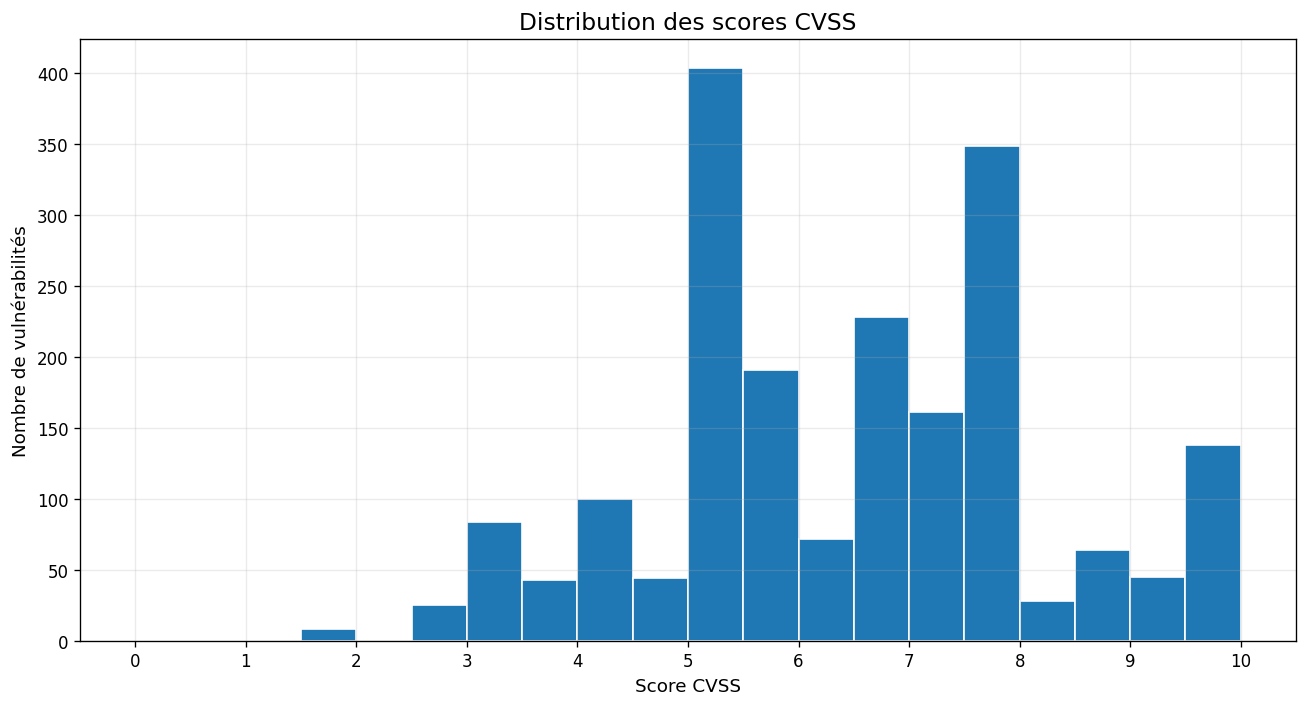

In [11]:
x = df["Score_CVSS"].dropna()
bins = np.arange(0, 10.5, 0.5)

plt.figure()
plt.hist(x, bins=bins, edgecolor="white", linewidth=1.0)
plt.title("Distribution des scores CVSS")
plt.xlabel("Score CVSS")
plt.ylabel("Nombre de vulnérabilités")
plt.xticks(np.arange(0, 11, 1))
plt.tight_layout()
plt.show()



Le graphique ci-dessus représente la distribution des scores CVSS (Common Vulnerability Scoring System) des vulnérabilités identifiées dans les bulletins analysés.
L’axe horizontal correspond au score CVSS, compris entre 0 et 10, tandis que l’axe vertical indique le nombre de vulnérabilités associées à chaque intervalle de score.

On observe que la majorité des vulnérabilités se concentre dans des scores compris entre 5 et 8, ce qui correspond principalement aux niveaux de gravité Medium à High selon la classification CVSS. Les scores faibles (inférieurs à 4) sont relativement peu représentés, indiquant que les vulnérabilités de faible impact sont moins fréquentes dans les bulletins publiés.

Par ailleurs, la présence non négligeable de scores élevés, notamment au-delà de 9, met en évidence l’existence de vulnérabilités critiques, susceptibles d’avoir un impact majeur sur la confidentialité, l’intégrité ou la disponibilité des systèmes concernés. Ces vulnérabilités nécessitent généralement une priorisation immédiate en matière de gestion des correctifs.

Dans l’ensemble, cette distribution suggère que les vulnérabilités rapportées par l’ANSSI concernent majoritairement des failles présentant un niveau de risque significatif, ce qui souligne l’importance d’une surveillance continue et d’une politique de remédiation efficace.

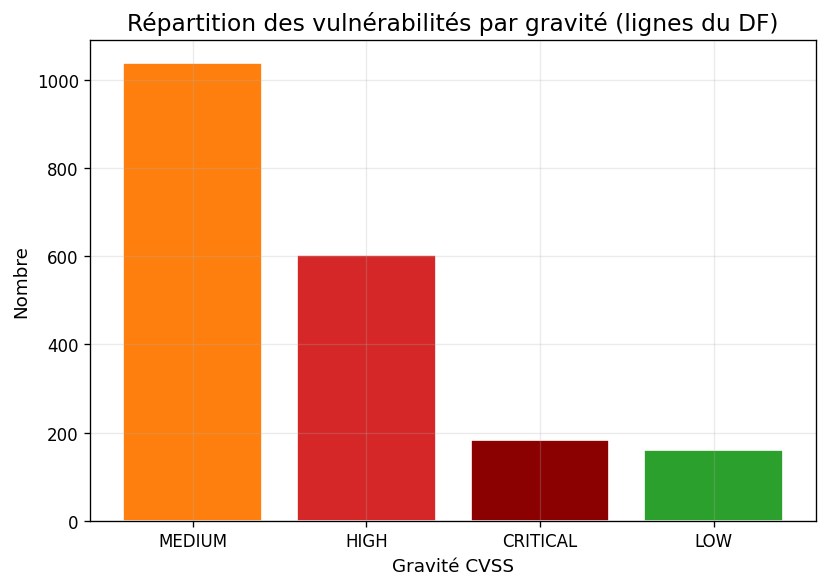

In [26]:
counts = (
    df["Gravite_CVSS"]
    .astype(str)
    .str.upper()
    .value_counts()
)

colors = {
    "LOW": "#2ca02c",
    "MEDIUM": "#ff7f0e",
    "HIGH": "#d62728",
    "CRITICAL": "#8b0000"
}

counts_no_unknown = counts.drop("INCONNU", errors="ignore")
bar_colors = [colors.get(g, "#7f7f7f") for g in counts_no_unknown.index]

plt.figure(figsize=(7, 5), dpi=120)
plt.bar(
    counts_no_unknown.index,
    counts_no_unknown.values,
    color=bar_colors,
    edgecolor="white",
    linewidth=1.0
)

plt.title("Répartition des vulnérabilités par gravité (lignes du DF)")
plt.xlabel("Gravité CVSS")
plt.ylabel("Nombre")
plt.tight_layout()
plt.show()



Ce graphique présente la répartition des vulnérabilités uniques (CVE) selon leur niveau de gravité CVSS, en excluant la catégorie INCONNU afin d’éviter tout biais lié à des informations manquantes.
Contrairement aux analyses basées sur le nombre de lignes du jeu de données, cette représentation repose sur un regroupement par identifiant CVE, garantissant qu’une vulnérabilité n’est comptabilisée qu’une seule fois.

On observe que les vulnérabilités de gravité MEDIUM sont les plus nombreuses, suivies par celles de gravité HIGH. Les vulnérabilités CRITICAL, bien que moins fréquentes, représentent néanmoins une part significative et correspondent à des failles à impact élevé, nécessitant généralement une prise en charge prioritaire. À l’inverse, les vulnérabilités de faible gravité (LOW) sont minoritaires dans le jeu de données.

Cette répartition met en évidence que la majorité des vulnérabilités publiées présentent un niveau de risque non négligeable, confirmant que les bulletins analysés se concentrent principalement sur des failles susceptibles d’avoir un impact opérationnel réel.

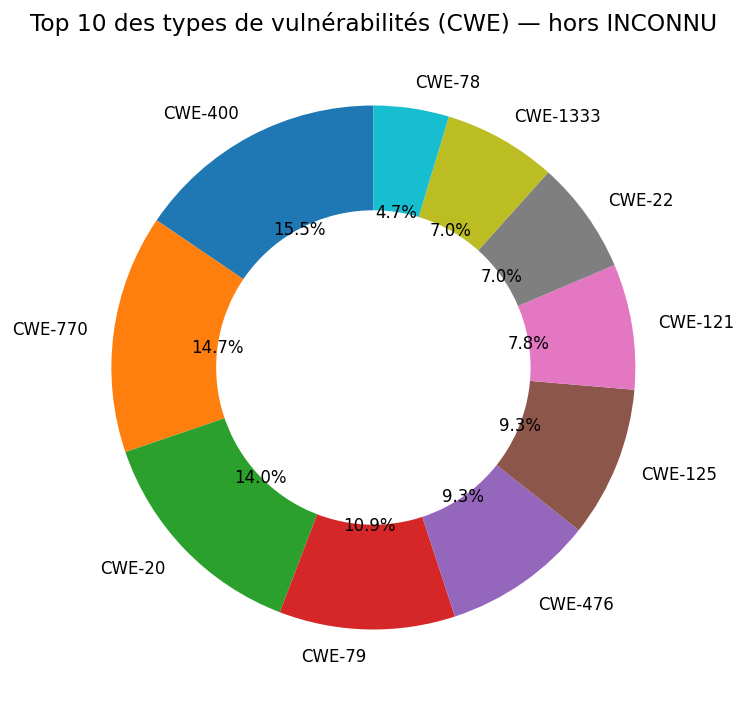

In [19]:
tmp = df[["ID_CVE", "Type_CWE"]].dropna(subset=["ID_CVE"]).copy()

tmp["Type_CWE"] = (
    tmp["Type_CWE"]
    .fillna("INCONNU")
    .astype(str)
    .replace({"": "INCONNU"})
)

cve_unique_cwe = (
    tmp
    .assign(is_known=lambda x: x["Type_CWE"] != "INCONNU")
    .sort_values("is_known")
    .groupby("ID_CVE", as_index=False)
    .last()   # garde un CWE renseigné s'il existe
)

counts_no_unknown = (
    cve_unique_cwe["Type_CWE"]
    .value_counts()
    .drop("Inconnu", errors="ignore")
    .drop("Non disponible", errors="ignore")
    .head(10)
)

plt.figure(figsize=(8, 6), dpi=120)
plt.pie(
    counts_no_unknown.values,
    labels=counts_no_unknown.index,
    autopct=lambda p: f"{p:.1f}%" if p >= 3 else "",
    startangle=90
)

centre = plt.Circle((0, 0), 0.60, fc="white")
plt.gca().add_artist(centre)

plt.title("Top 10 des types de vulnérabilités (CWE) — hors INCONNU")
plt.tight_layout()
plt.show()



Ce graphique présente la répartition des dix types de vulnérabilités (CWE) les plus fréquemment observés parmi les CVE uniques, en excluant la catégorie INCONNU afin d’éliminer les biais liés aux informations manquantes.
Chaque part du diagramme correspond à la proportion d’un type de vulnérabilité spécifique par rapport à l’ensemble des CVE pour lesquelles un CWE est renseigné.

On constate que certaines catégories de failles sont particulièrement représentées. Les CWE CWE-400, CWE-770 et CWE-20 figurent parmi les plus fréquentes. Ces vulnérabilités sont principalement liées à des problèmes de gestion des ressources (CWE-400, CWE-770) et à une validation insuffisante des entrées (CWE-20), deux causes récurrentes de failles de sécurité.

D’autres types de vulnérabilités notables apparaissent également, tels que CWE-79 (Cross-Site Scripting), CWE-476 (Null Pointer Dereference) ou CWE-125 (Out-of-bounds Read), qui sont des failles bien connues et souvent exploitées dans des contextes applicatifs ou systèmes.

Dans l’ensemble, cette répartition met en évidence que les vulnérabilités les plus fréquentes relèvent majoritairement de problèmes de conception ou de validation, soulignant l’importance de bonnes pratiques de développement sécurisé, notamment en matière de gestion des entrées utilisateur et de contrôle des ressources.

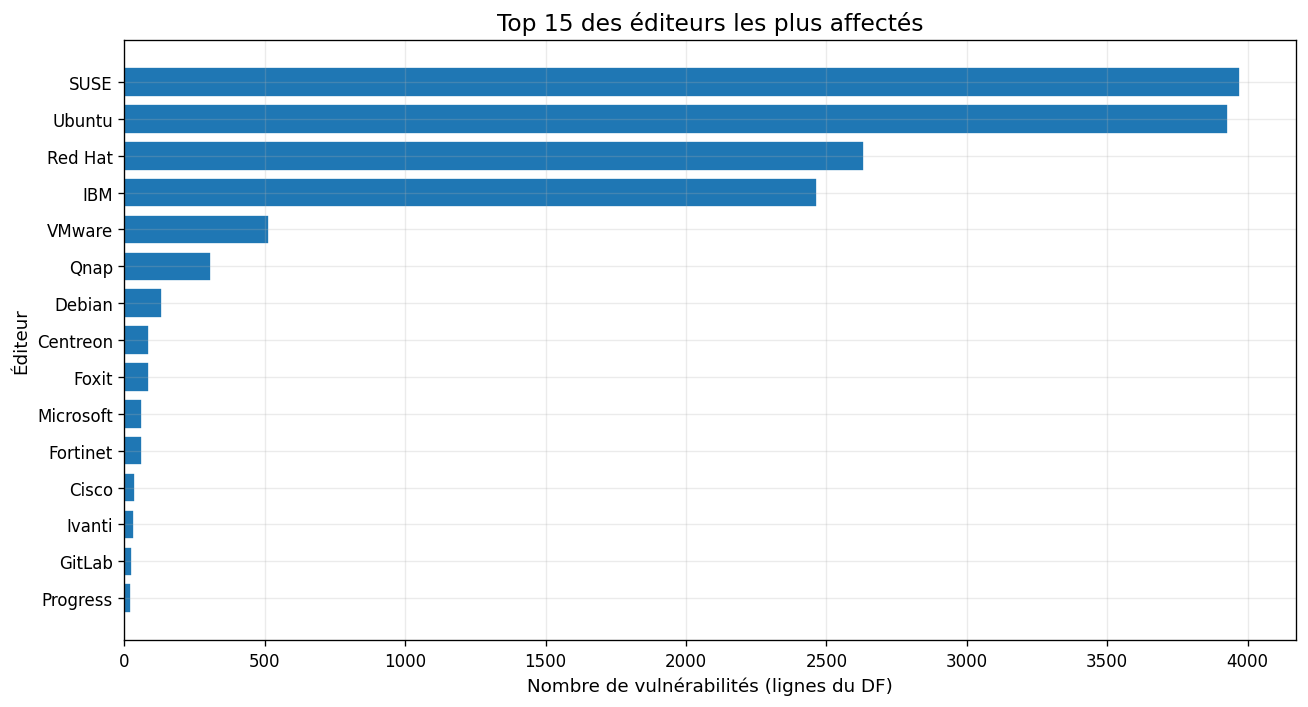

In [14]:
top_n = 15
counts = (
    df["Éditeur"]
    .fillna("Non renseigné")
    .astype(str)
    .replace({"": "Non renseigné"})
    .value_counts()
    .head(top_n)
    .sort_values()
)

plt.figure()
plt.barh(counts.index, counts.values, edgecolor="white", linewidth=1.0)
plt.title(f"Top {top_n} des éditeurs les plus affectés")
plt.xlabel("Nombre de vulnérabilités (lignes du DF)")
plt.ylabel("Éditeur")
plt.tight_layout()
plt.show()


Ce graphique présente le classement des quinze éditeurs les plus affectés par des vulnérabilités, sur la base du nombre d’occurrences recensées dans les bulletins analysés. L’axe horizontal indique le nombre de vulnérabilités identifiées, tandis que l’axe vertical correspond aux éditeurs concernés.

On observe une forte concentration des vulnérabilités autour de quelques éditeurs majeurs. Les distributions SUSE et Ubuntu apparaissent comme les plus représentées, suivies par Red Hat et IBM. Cette sur-représentation s’explique notamment par la large base installée de ces solutions et par leur forte exposition dans les environnements professionnels, ce qui entraîne une surveillance accrue et une publication plus fréquente de bulletins de sécurité.

Les éditeurs suivants, tels que VMware ou QNAP, présentent un nombre de vulnérabilités plus modéré, tandis que la majorité des autres éditeurs du classement affichent des volumes nettement plus faibles. Cette distribution met en évidence un effet de concentration, où un nombre restreint d’éditeurs regroupe une part significative des vulnérabilités recensées.

Il est important de noter que ce graphique reflète le nombre d’occurrences de vulnérabilités dans les bulletins, et non nécessairement le nombre de CVE uniques par éditeur. Il doit donc être interprété comme un indicateur d’exposition et de visibilité des éditeurs dans les publications, plutôt que comme une mesure directe de la qualité de sécurité de leurs produits.

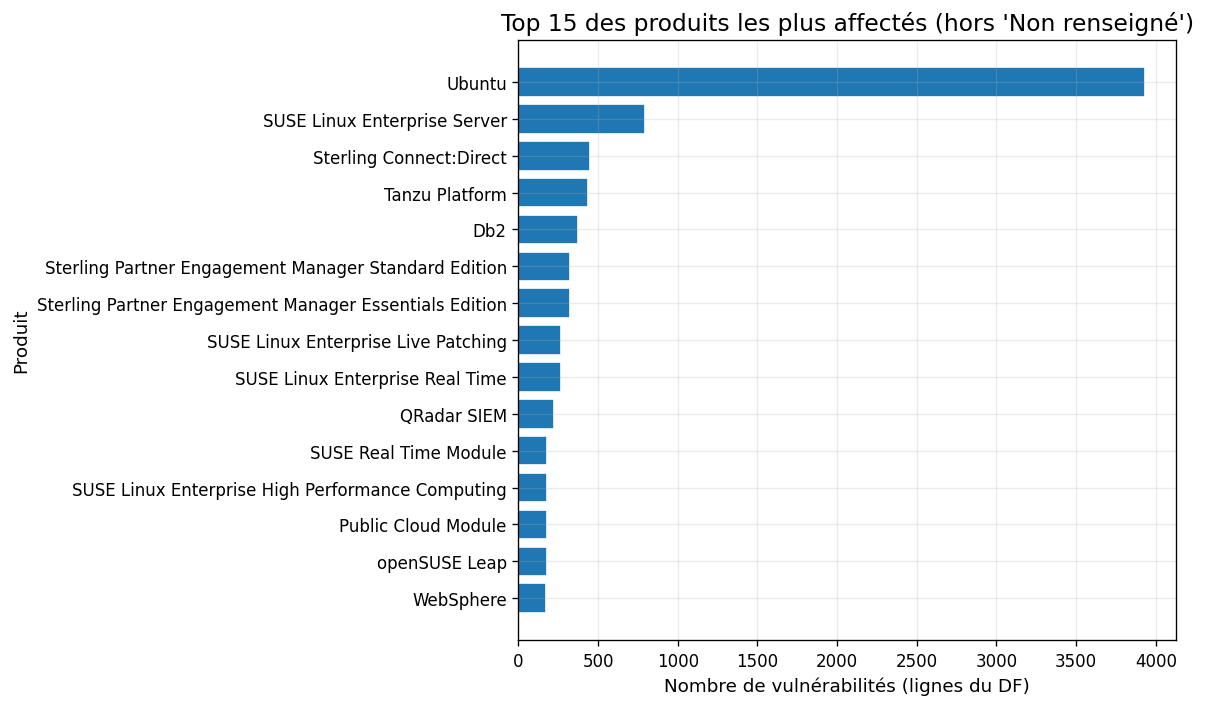

In [ ]:
top_n = 15

counts = (
    df["Produit"]
    .dropna()
    .astype(str)
    .replace({"": None})
    .dropna()
    .loc[lambda x: x != "Non renseigné"]
    .value_counts()
    .head(top_n)
    .sort_values()
)

plt.figure(figsize=(10, 6), dpi=120)
plt.barh(counts.index, counts.values, edgecolor="white", linewidth=1.0)
plt.title(f"Top {top_n} des produits les plus affectés (hors 'Non renseigné')")
plt.xlabel("Nombre de vulnérabilités (lignes du DF)")
plt.ylabel("Produit")
plt.tight_layout()
plt.show()


Ce graphique présente le classement des quinze produits les plus affectés par des vulnérabilités, en excluant les entrées « Non renseigné » afin d’éliminer les biais liés aux informations manquantes. L’axe horizontal représente le nombre d’occurrences de vulnérabilités recensées dans les bulletins analysés, tandis que l’axe vertical correspond aux produits concernés.

On observe que Ubuntu se distingue très nettement comme le produit le plus fréquemment cité, avec un volume de vulnérabilités largement supérieur aux autres produits du classement. Cette forte représentation peut s’expliquer par sa large diffusion, son cycle de mises à jour régulier et une surveillance accrue de sa surface d’attaque.

Le produit SUSE Linux Enterprise Server arrive en deuxième position, suivi par plusieurs solutions professionnelles, notamment des produits de l’écosystème IBM (Sterling, Db2, WebSphere) ainsi que des plateformes d’infrastructure telles que Tanzu Platform ou QRadar SIEM. Ces produits sont majoritairement déployés dans des environnements critiques, ce qui explique la fréquence des vulnérabilités signalées.

La distribution globale met en évidence un effet de concentration, où un nombre restreint de produits concentre une part importante des vulnérabilités publiées, tandis que les autres produits présentent des volumes plus limités. Ce graphique doit toutefois être interprété comme une mesure de présence dans les bulletins, et non comme une évaluation directe du niveau de sécurité intrinsèque de chaque produit.

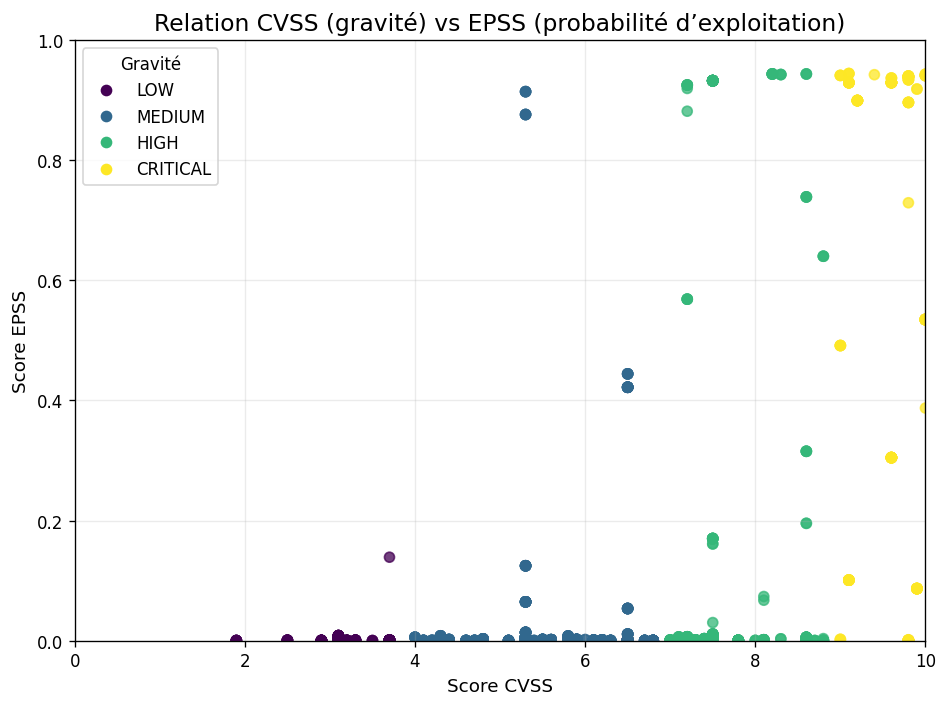

In [21]:
tmp = df[["Score_CVSS", "Score_EPSS", "Gravite_CVSS"]].dropna()

order = ["LOW", "MEDIUM", "HIGH", "CRITICAL"]
tmp["Gravite_CVSS"] = tmp["Gravite_CVSS"].astype(str).str.upper()

code = tmp["Gravite_CVSS"].map({k: i for i, k in enumerate(order)}).astype(int)

# Nouvelle API Matplotlib
cmap = plt.colormaps["viridis"].resampled(len(order))

plt.figure(figsize=(8, 6), dpi=120)
plt.scatter(
    tmp["Score_CVSS"],
    tmp["Score_EPSS"],
    c=code,
    cmap=cmap,
    alpha=0.75
)

plt.title("Relation CVSS (gravité) vs EPSS (probabilité d’exploitation)")
plt.xlabel("Score CVSS")
plt.ylabel("Score EPSS")
plt.xlim(0, 10)
plt.ylim(0, 1)

handles = [
    plt.Line2D(
        [0], [0],
        marker='o',
        linestyle='',
        color=cmap(i),
        label=k
    )
    for i, k in enumerate(order)
    if k in tmp["Gravite_CVSS"].values
]

plt.legend(handles=handles, title="Gravité")
plt.tight_layout()
plt.show()


Ce graphique met en relation le score CVSS, qui mesure la gravité intrinsèque d’une vulnérabilité, et le score EPSS, qui estime sa probabilité d’exploitation effective. Chaque point représente une vulnérabilité unique, et la couleur indique son niveau de gravité CVSS (LOW, MEDIUM, HIGH, CRITICAL).

L’analyse montre qu’il n’existe pas de corrélation linéaire systématique entre la gravité d’une vulnérabilité et sa probabilité d’exploitation. En effet, certaines vulnérabilités présentant un score CVSS élevé affichent une probabilité d’exploitation faible, tandis que d’autres, parfois de gravité intermédiaire, présentent des scores EPSS relativement élevés.

On observe néanmoins que les vulnérabilités CRITICAL et HIGH concentrent la majorité des valeurs EPSS élevées. Ces points situés dans la partie supérieure droite du graphique correspondent à des failles à la fois très graves et fortement exploitables, représentant ainsi les risques les plus critiques en termes de sécurité opérationnelle.

À l’inverse, les vulnérabilités de gravité LOW et MEDIUM se situent majoritairement dans des zones de faible probabilité d’exploitation, ce qui suggère un impact opérationnel plus limité, bien que ces failles ne doivent pas être négligées.

Ce graphique illustre l’intérêt de croiser les métriques CVSS et EPSS afin d’obtenir une vision plus fine du risque réel, et montre que la priorisation des vulnérabilités ne peut pas reposer uniquement sur la gravité CVSS, mais doit également prendre en compte la probabilité d’exploitation.

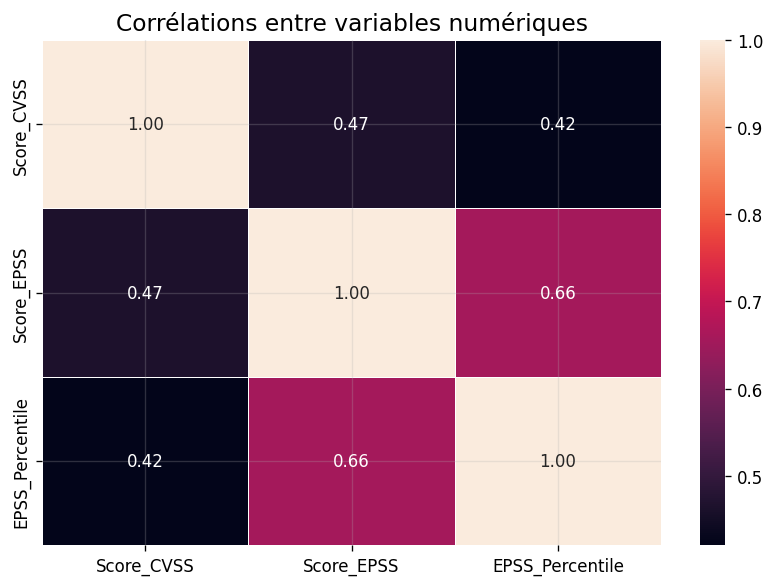

In [20]:
num_cols = ["Score_CVSS", "Score_EPSS", "EPSS_Percentile"]
num_df = df[num_cols].dropna(how="all")
corr = num_df.corr(numeric_only=True)

plt.figure(figsize=(7, 5), dpi=120)
sns.heatmap(corr, annot=True, fmt=".2f", linewidths=0.5)


plt.title("Corrélations entre variables numériques")
plt.tight_layout()
plt.show()


Ce graphique représente la matrice de corrélation entre les principales variables numériques du jeu de données, à savoir le score CVSS, le score EPSS et le percentile EPSS. Chaque cellule indique le coefficient de corrélation linéaire entre deux variables, compris entre −1 et 1, où une valeur proche de 1 traduit une corrélation positive forte, et une valeur proche de 0 une corrélation faible.

On observe tout d’abord une corrélation modérée entre le score CVSS et le score EPSS (≈ 0,47). Cela suggère que les vulnérabilités les plus graves tendent, en moyenne, à présenter une probabilité d’exploitation plus élevée, sans pour autant établir un lien systématique entre ces deux dimensions. La gravité intrinsèque d’une vulnérabilité n’est donc pas suffisante, à elle seule, pour prédire son exploitabilité.

La corrélation entre le score CVSS et le percentile EPSS est également modérée (≈ 0,42), confirmant que les vulnérabilités les plus sévères ne sont pas nécessairement celles qui se situent parmi les plus exploitables à l’échelle globale.

En revanche, la corrélation entre le score EPSS et le percentile EPSS est plus élevée (≈ 0,66), ce qui est cohérent puisque ces deux indicateurs mesurent des aspects proches de l’exploitabilité : le score EPSS représentant une probabilité brute, et le percentile EPSS une position relative par rapport à l’ensemble des vulnérabilités connues.

Dans l’ensemble, cette matrice met en évidence l’intérêt de combiner plusieurs indicateurs pour évaluer le risque réel d’une vulnérabilité. Elle confirme que la gravité (CVSS) et l’exploitabilité (EPSS) apportent des informations complémentaires, justifiant leur utilisation conjointe dans les processus de priorisation des vulnérabilités.

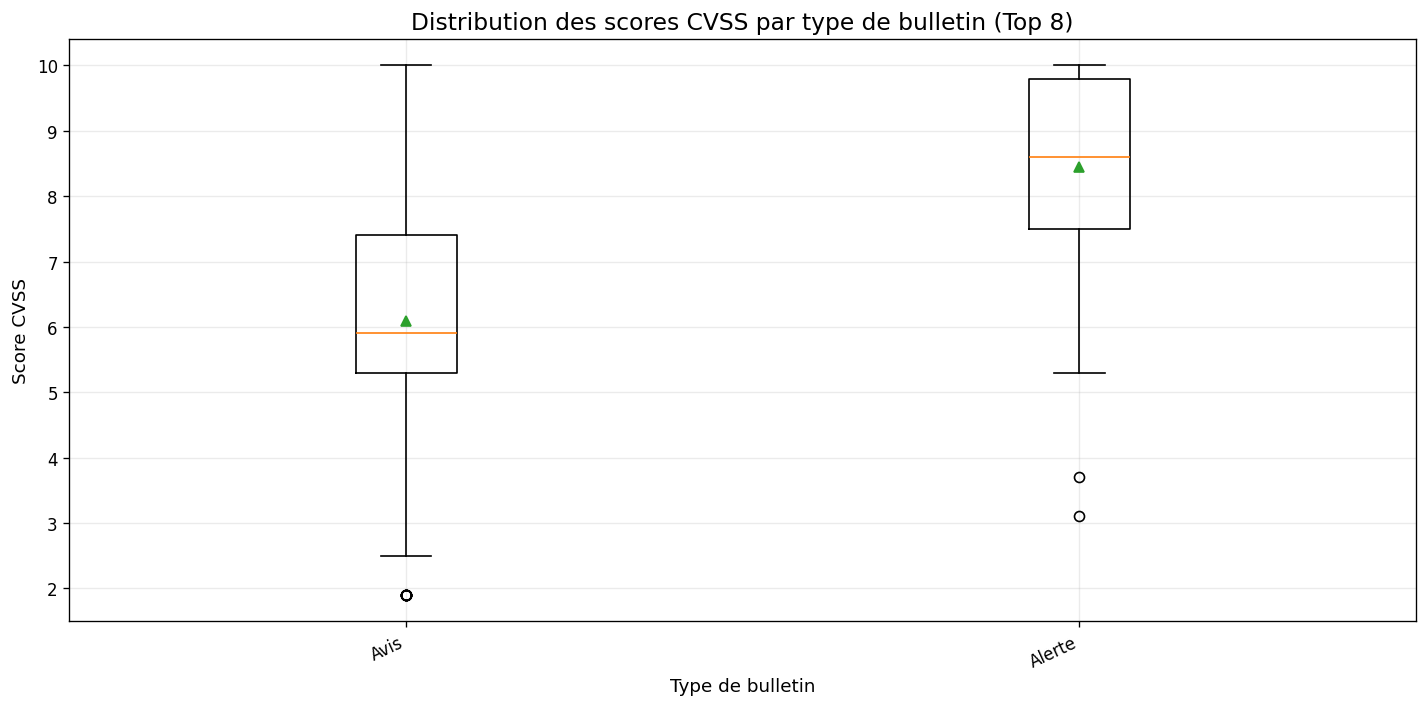

In [16]:
tmp = df[["Type_de_Bulletin", "Score_CVSS"]].dropna()
# prend les 8 types les plus fréquents pour lisibilité
top_types = tmp["Type_de_Bulletin"].value_counts().head(8).index
tmp = tmp[tmp["Type_de_Bulletin"].isin(top_types)]

groups = [tmp.loc[tmp["Type_de_Bulletin"] == t, "Score_CVSS"].values for t in top_types]

plt.figure(figsize=(12, 6), dpi=120)
plt.boxplot(groups, tick_labels=top_types, showmeans=True)
plt.title("Distribution des scores CVSS par type de bulletin (Top 8)")
plt.xlabel("Type de bulletin")
plt.ylabel("Score CVSS")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


Ce graphique compare la distribution des scores CVSS en fonction du type de bulletin publié par l’ANSSI, en distinguant les avis et les alertes. Les boîtes à moustaches représentent la dispersion des scores CVSS pour chaque catégorie, en mettant en évidence la médiane, les quartiles ainsi que les valeurs extrêmes. Le marqueur triangulaire indique la valeur moyenne du score CVSS pour chaque type de bulletin.

On observe une différence nette entre les deux catégories. Les alertes présentent des scores CVSS globalement plus élevés que les avis, avec une médiane située dans une zone de gravité élevée, et une moyenne proche des niveaux critiques. Cette distribution confirme que les alertes sont principalement utilisées pour signaler des vulnérabilités présentant un impact important et immédiat sur la sécurité des systèmes.

À l’inverse, les avis affichent une distribution plus étalée, avec une médiane située dans la catégorie Medium, et une dispersion plus importante des scores. La présence de valeurs faibles parmi les avis montre que ce type de bulletin couvre un spectre plus large de gravité, incluant des vulnérabilités de moindre impact.

Les valeurs atypiques (outliers) observées dans les deux catégories traduisent l’existence de cas particuliers, tels que des vulnérabilités très graves signalées sous forme d’avis, ou, plus rarement, des alertes associées à des scores CVSS légèrement inférieurs à la médiane.

Dans l’ensemble, ce graphique met en évidence la cohérence du processus de publication des bulletins ANSSI, où le type de bulletin est étroitement lié au niveau de gravité des vulnérabilités signalées.

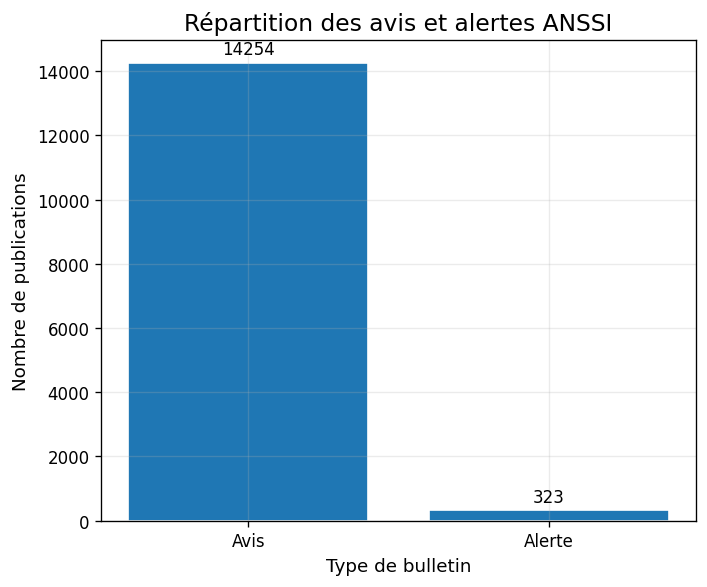

In [3]:
# Comptage des types de bulletin
counts = (
    df["Type_de_Bulletin"]
    .fillna("Non renseigné")
    .astype(str)
    .replace({"": "Non renseigné"})
    .value_counts()
)

plt.figure(figsize=(6, 5), dpi=120)
plt.bar(counts.index, counts.values, edgecolor="white", linewidth=1.0)

plt.title("Répartition des avis et alertes ANSSI")
plt.xlabel("Type de bulletin")
plt.ylabel("Nombre de publications")

# Affichage des valeurs sur les barres
for i, v in enumerate(counts.values):
    plt.text(i, v + counts.max()*0.01, str(v), ha="center", va="bottom")

plt.tight_layout()
plt.show()


Ce graphique présente la répartition des publications de l’ANSSI entre les avis et les alertes. L’axe horizontal distingue les deux types de bulletins, tandis que l’axe vertical indique le nombre total de publications associées à chacun.

On observe une forte prédominance des avis, qui représentent l’immense majorité des publications, avec plus de 14 000 avis recensés sur la période étudiée, contre seulement quelques centaines d’alertes. Cette différence marquée illustre le rôle distinct de ces deux types de bulletins dans la stratégie de communication de l’ANSSI.

Les avis sont principalement utilisés pour diffuser de l’information sur un large éventail de vulnérabilités, incluant des failles de gravité variable et des recommandations de mise à jour ou de bonnes pratiques. À l’inverse, les alertes sont beaucoup plus rares et sont réservées à des situations jugées particulièrement critiques, nécessitant une attention immédiate de la part des acteurs concernés.

Cette répartition confirme que les alertes constituent un outil ciblé et exceptionnel, tandis que les avis assurent une veille de sécurité continue et plus exhaustive.

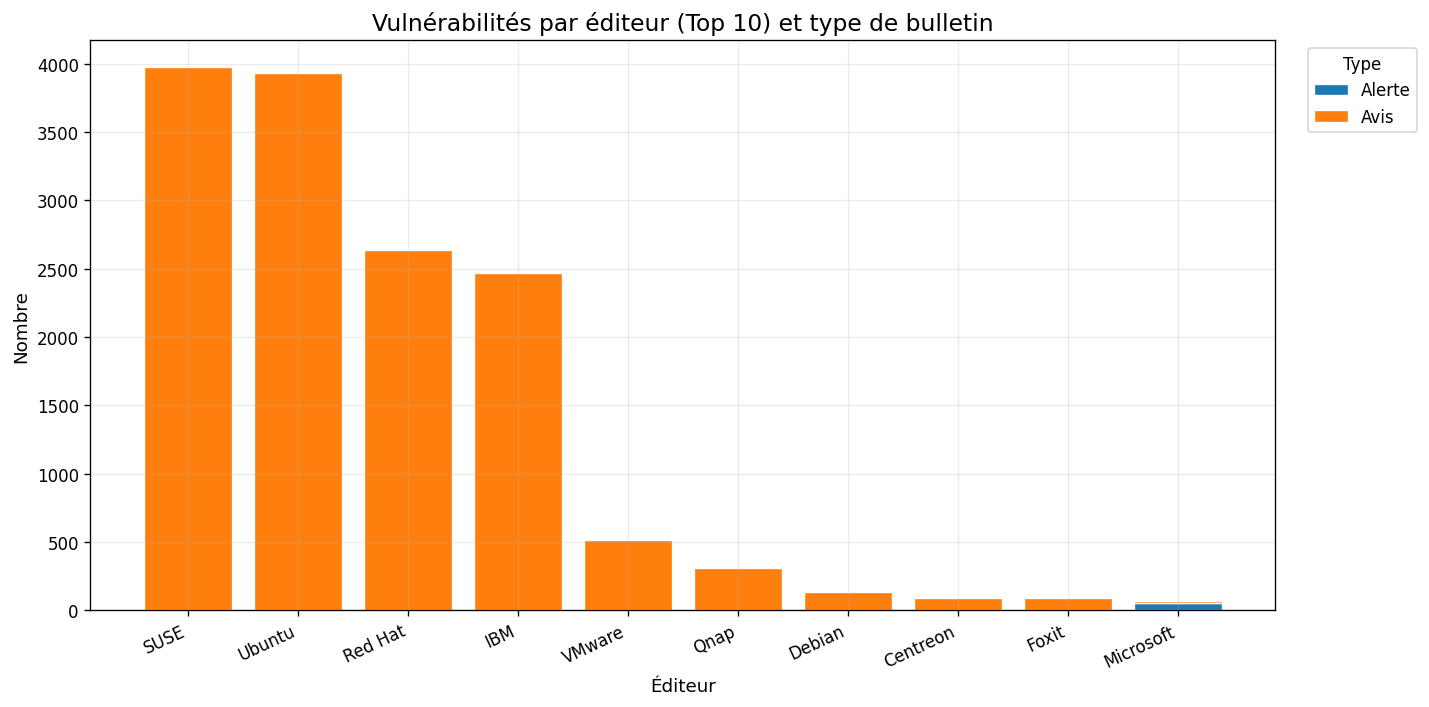

In [ ]:
top_n = 10
tmp = df[["Éditeur", "Type_de_Bulletin"]].dropna()

top_vendors = tmp["Éditeur"].value_counts().head(top_n).index
tmp = tmp[tmp["Éditeur"].isin(top_vendors)]

pivot = pd.crosstab(tmp["Éditeur"], tmp["Type_de_Bulletin"]).loc[top_vendors]

plt.figure(figsize=(12, 6), dpi=120)
bottom = np.zeros(len(pivot))
for col in pivot.columns:
    plt.bar(pivot.index, pivot[col].values, bottom=bottom, label=col, edgecolor="white", linewidth=0.8)
    bottom += pivot[col].values

plt.title(f"Vulnérabilités par éditeur (Top {top_n}) et type de bulletin")
plt.xlabel("Éditeur")
plt.ylabel("Nombre")
plt.xticks(rotation=25, ha="right")
plt.legend(title="Type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


Ce graphique présente, pour les dix éditeurs les plus représentés, le nombre de vulnérabilités recensées dans les bulletins ANSSI, en distinguant les deux catégories de publications : avis et alertes. Les barres empilées permettent ainsi de visualiser à la fois le volume total associé à chaque éditeur et la répartition entre avis et alertes.

On observe une forte concentration des vulnérabilités sur un nombre restreint d’éditeurs. Les éditeurs SUSE et Ubuntu dominent nettement le classement, suivis par Red Hat et IBM, ce qui suggère une forte exposition de ces environnements dans les bulletins analysés. Cette sur-représentation peut s’expliquer par leur large diffusion dans les systèmes d’information (en particulier côté serveurs et infrastructures) ainsi que par une veille et une publication de correctifs très actives.

La composante “Alerte” apparaît globalement faible par rapport aux avis, ce qui est cohérent avec la répartition globale observée précédemment : les alertes sont plus rares et généralement réservées aux situations les plus critiques. Néanmoins, ce graphique reste pertinent car il permet d’identifier, éditeur par éditeur, si des alertes sont présentes et dans quelle mesure elles contribuent au volume total.

Enfin, ce graphique doit être interprété comme une mesure de présence dans les bulletins (nombre d’occurrences dans le dataset) et non comme un décompte strict de CVE uniques : un même identifiant CVE peut apparaître plusieurs fois selon les bulletins ou les contextes produits/versions associés.

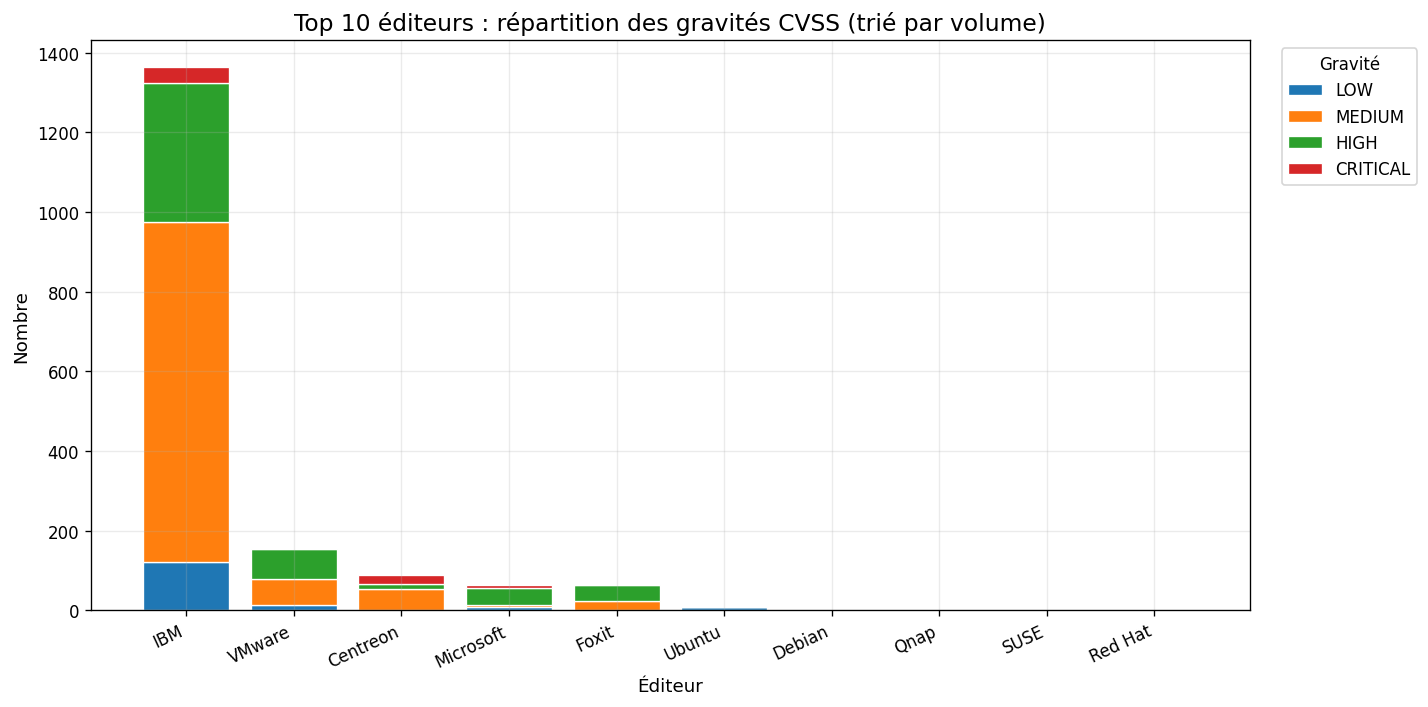

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

tmp = df[["Éditeur", "Gravite_CVSS"]].dropna().copy()
tmp["Gravite_CVSS"] = tmp["Gravite_CVSS"].astype(str).str.upper()

# Top 10 éditeurs par volume (occurrences)
top_v = tmp["Éditeur"].value_counts().head(10).index
tmp = tmp[tmp["Éditeur"].isin(top_v)]

pivot = pd.crosstab(tmp["Éditeur"], tmp["Gravite_CVSS"])

# Colonnes attendues
for col in ["LOW", "MEDIUM", "HIGH", "CRITICAL"]:
    if col not in pivot.columns:
        pivot[col] = 0
pivot = pivot[["LOW", "MEDIUM", "HIGH", "CRITICAL"]]

# ✅ Tri décroissant par total
pivot = pivot.assign(Total=pivot.sum(axis=1)).sort_values("Total", ascending=False).drop(columns="Total")

plt.figure(figsize=(12, 6), dpi=120)
bottom = np.zeros(len(pivot))
for col in pivot.columns:
    plt.bar(pivot.index, pivot[col].values, bottom=bottom, label=col, edgecolor="white", linewidth=0.8)
    bottom += pivot[col].values

plt.title("Top 10 éditeurs : répartition des gravités CVSS (trié par volume)")
plt.xlabel("Éditeur")
plt.ylabel("Nombre")
plt.xticks(rotation=25, ha="right")
plt.legend(title="Gravité", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# A vérifier si les données correspondent ou pas parce qu'il parait incomplet voire faux

Ce graphique présente, pour les dix éditeurs les plus représentés, la répartition des vulnérabilités par niveau de gravité CVSS (LOW, MEDIUM, HIGH, CRITICAL). Les barres empilées sont triées par volume total décroissant, ce qui permet d’identifier immédiatement les éditeurs concentrant le plus grand nombre de vulnérabilités recensées dans les bulletins analysés.

On observe une domination très nette d’IBM, dont le volume total de vulnérabilités est largement supérieur à celui des autres éditeurs du classement. Cette sur-représentation s’explique par la diversité et la complexité de l’écosystème de produits IBM, largement déployés en environnements professionnels, ainsi que par une publication fréquente de bulletins de sécurité.

La majorité des vulnérabilités associées à IBM se situe dans les catégories MEDIUM et HIGH, avec une présence plus limitée de vulnérabilités CRITICAL. Ce profil suggère un volume important de failles significatives, sans pour autant indiquer une proportion exceptionnellement élevée de vulnérabilités critiques.

Les éditeurs suivants, tels que VMware, Centreon, Microsoft ou Foxit, présentent des volumes nettement plus faibles. Toutefois, malgré ce faible nombre absolu, on observe chez certains d’entre eux une part non négligeable de vulnérabilités de gravité HIGH ou CRITICAL, ce qui souligne que même un faible volume peut recouvrir des risques importants.

Enfin, les éditeurs placés en fin de classement (Ubuntu, Debian, Qnap, SUSE, Red Hat) affichent des volumes très réduits dans ce graphique, ce qui limite la pertinence d’une comparaison directe en valeur absolue. Pour ces éditeurs, une analyse normalisée ou basée sur les CVE uniques serait plus appropriée afin d’évaluer leur profil de gravité de manière plus fine.

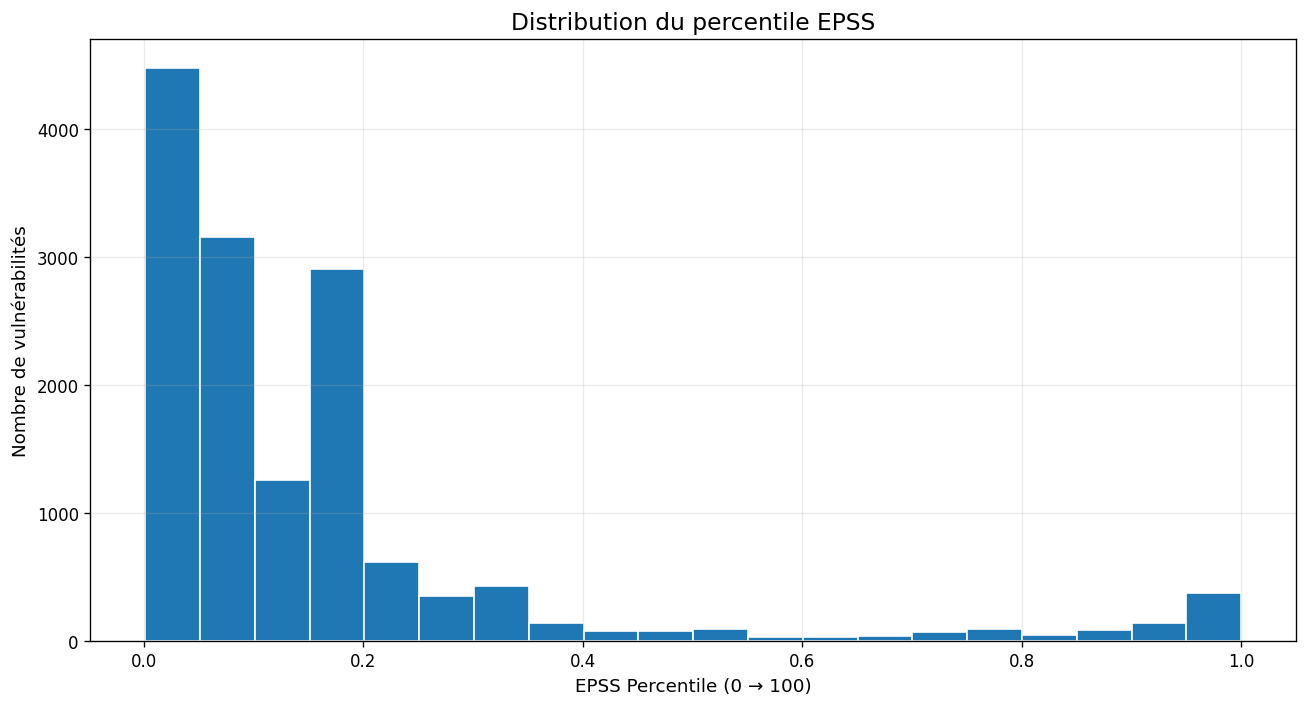

In [31]:
x = df["EPSS_Percentile"].dropna()

plt.figure()
plt.hist(x, bins=20, edgecolor="white", linewidth=1.0)
plt.title("Distribution du percentile EPSS")
plt.xlabel("EPSS Percentile (0 → 100)")
plt.ylabel("Nombre de vulnérabilités")
plt.tight_layout()
plt.show()


Ce graphique représente la distribution du percentile EPSS pour l’ensemble des vulnérabilités étudiées. Le percentile EPSS mesure la probabilité relative d’exploitation d’une vulnérabilité par rapport à l’ensemble des vulnérabilités connues : plus le percentile est élevé, plus la vulnérabilité est susceptible d’être exploitée activement.

On observe une distribution très asymétrique, fortement concentrée vers les faibles percentiles EPSS. La majorité des vulnérabilités se situe dans les percentiles les plus bas, indiquant que, prises individuellement, peu de vulnérabilités présentent une forte probabilité d’exploitation. Cette concentration est cohérente avec les observations générales sur les bases de données de vulnérabilités, où seules quelques failles sont exploitées de manière active à grande échelle.

À l’opposé, une minorité de vulnérabilités se distingue par des percentiles EPSS élevés, proches de 1. Ces vulnérabilités représentent des cas à risque prioritaire, car elles combinent une forte probabilité d’exploitation avec un impact potentiel élevé. Même si leur nombre est limité, leur présence justifie une priorisation spécifique dans les processus de gestion des correctifs et de surveillance.

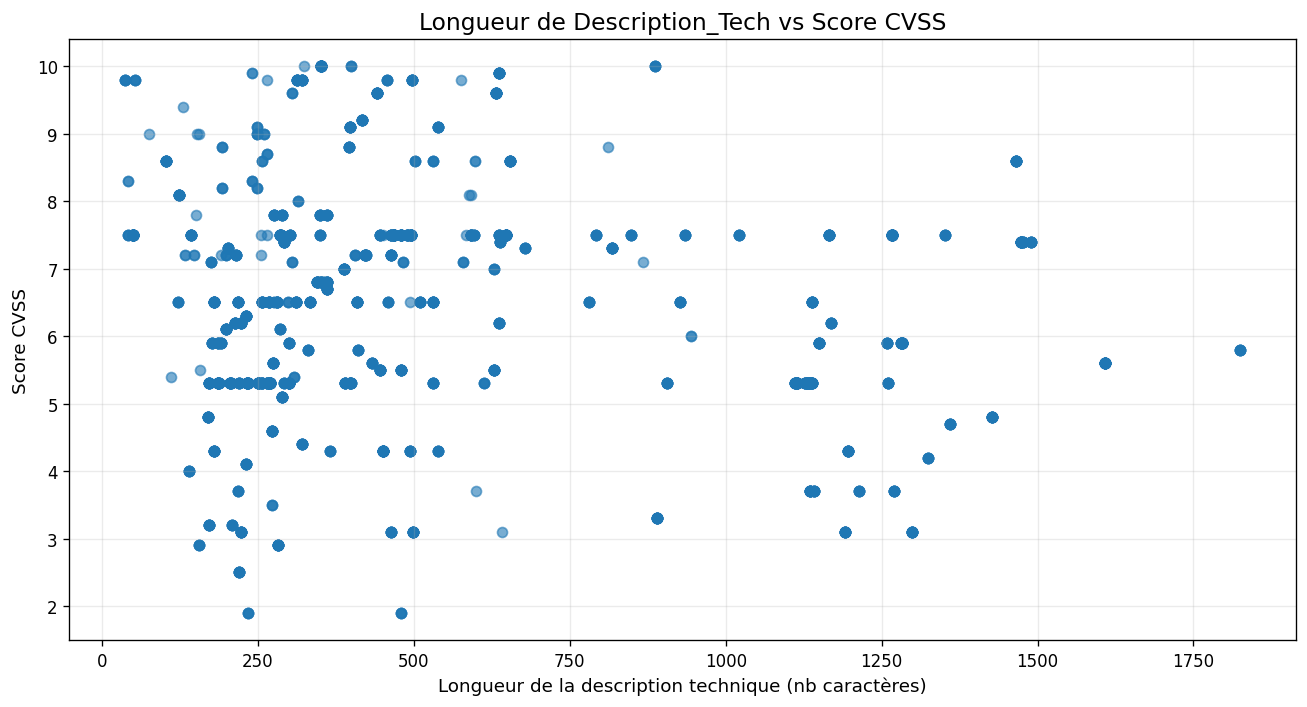

In [35]:
tmp = df[["Description_Tech", "Score_CVSS"]].dropna().copy()
tmp["len_desc"] = tmp["Description_Tech"].astype(str).str.len()

# On coupe les extrêmes pour que le graphe soit lisible (optionnel)
q99 = tmp["len_desc"].quantile(0.99)
tmp = tmp[tmp["len_desc"] <= q99]

plt.figure()
plt.scatter(tmp["len_desc"], tmp["Score_CVSS"], alpha=0.6)
plt.title("Longueur de Description_Tech vs Score CVSS")
plt.xlabel("Longueur de la description technique (nb caractères)")
plt.ylabel("Score CVSS")
plt.tight_layout()
plt.show()


Ce graphique représente la relation entre la longueur de la description technique d’une vulnérabilité (exprimée en nombre de caractères) et son score CVSS, qui mesure la gravité de la vulnérabilité. Chaque point correspond à une vulnérabilité identifiée dans les bulletins ANSSI.

On observe une forte dispersion des points, sans tendance linéaire clairement identifiable. Des vulnérabilités présentant des scores CVSS élevés (supérieurs à 8) apparaissent aussi bien pour des descriptions techniques courtes que très détaillées. À l’inverse, certaines descriptions longues sont associées à des scores CVSS modérés ou faibles.

Cette absence de corrélation marquée indique que la longueur de la description technique n’est pas un indicateur fiable de la gravité d’une vulnérabilité. Une vulnérabilité critique peut être décrite de manière concise lorsqu’elle est bien comprise ou standardisée, tandis qu’une vulnérabilité de gravité moyenne peut nécessiter une description plus longue en raison de sa complexité ou de son contexte technique.

Le graphique met également en évidence une concentration de points autour de longueurs intermédiaires (environ 200 à 500 caractères), ce qui suggère une certaine homogénéité dans le format des descriptions techniques publiées par l’ANSSI, indépendamment du niveau de gravité.

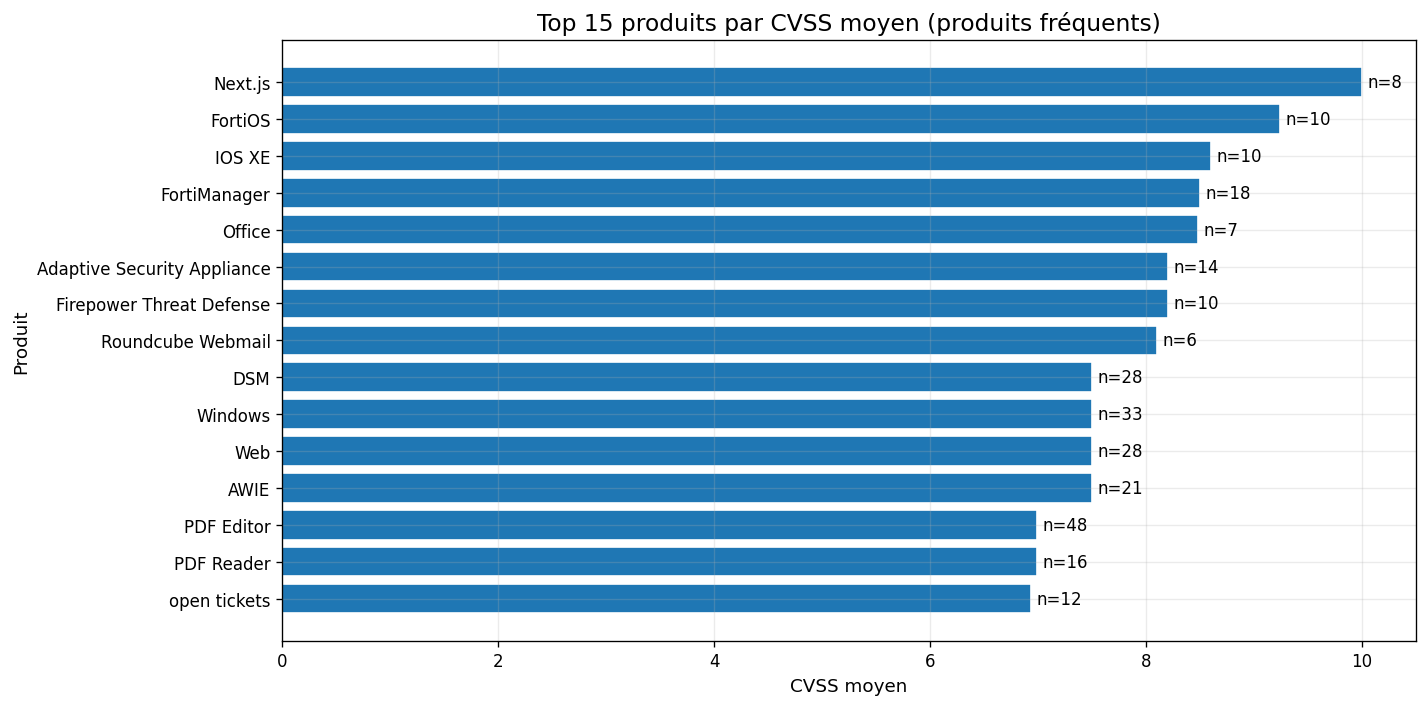

In [41]:
tmp = df[["Produit", "Score_CVSS"]].dropna().copy()
tmp["Produit"] = tmp["Produit"].astype(str).replace({"": "Non renseigné"}).fillna("Non renseigné")

stats = tmp.groupby("Produit")["Score_CVSS"].agg(count="count", mean="mean").reset_index()
stats = stats[stats["count"] >= 5].sort_values("mean", ascending=False).head(15)
stats = stats.sort_values("mean")  # barh

plt.figure(figsize=(12, 6), dpi=120)
bars = plt.barh(stats["Produit"], stats["mean"], edgecolor="white", linewidth=1.0)
plt.title("Top 15 produits par CVSS moyen (produits fréquents)")
plt.xlabel("CVSS moyen")
plt.ylabel("Produit")

# annotations: n=...
for rect, n in zip(bars, stats["count"]):
    plt.text(rect.get_width() + 0.05, rect.get_y() + rect.get_height()/2, f"n={n}", va="center")

plt.tight_layout()
plt.show()


Ce graphique présente les 15 produits les plus fréquemment mentionnés dans les bulletins ANSSI, classés selon leur score CVSS moyen. Le score CVSS moyen permet d’évaluer la gravité moyenne des vulnérabilités associées à chaque produit, tandis que l’indication n correspond au nombre de vulnérabilités prises en compte pour le calcul de cette moyenne.

On observe que certains produits affichent un score CVSS moyen très élevé, proche ou égal à 10, comme Next.js, FortiOS ou IOS XE. Cela signifie que, bien que le nombre de vulnérabilités recensées pour ces produits soit relativement limité (valeurs de n faibles), celles-ci sont en moyenne très critiques, ce qui représente un risque élevé pour les systèmes concernés.

À l’inverse, d’autres produits tels que Windows, Web ou PDF Editor présentent un score CVSS moyen plus modéré, malgré un nombre de vulnérabilités plus important. Cela suggère que ces produits sont exposés à un volume plus élevé de vulnérabilités, mais avec une gravité moyenne moins critique, traduisant une diversité de failles allant de gravités faibles à élevées.

Ce graphique met ainsi en évidence une distinction importante entre :

des produits peu fréquemment cités mais fortement critiques, nécessitant une vigilance immédiate malgré un faible volume de vulnérabilités ;

des produits très répandus, pour lesquels la gestion du risque repose davantage sur la quantité et la variabilité des vulnérabilités que sur leur gravité moyenne.

Il souligne enfin la nécessité d’interpréter le score CVSS moyen en tenant compte du nombre de vulnérabilités associées, afin d’éviter des conclusions biaisées lorsque l’effectif est trop faible.

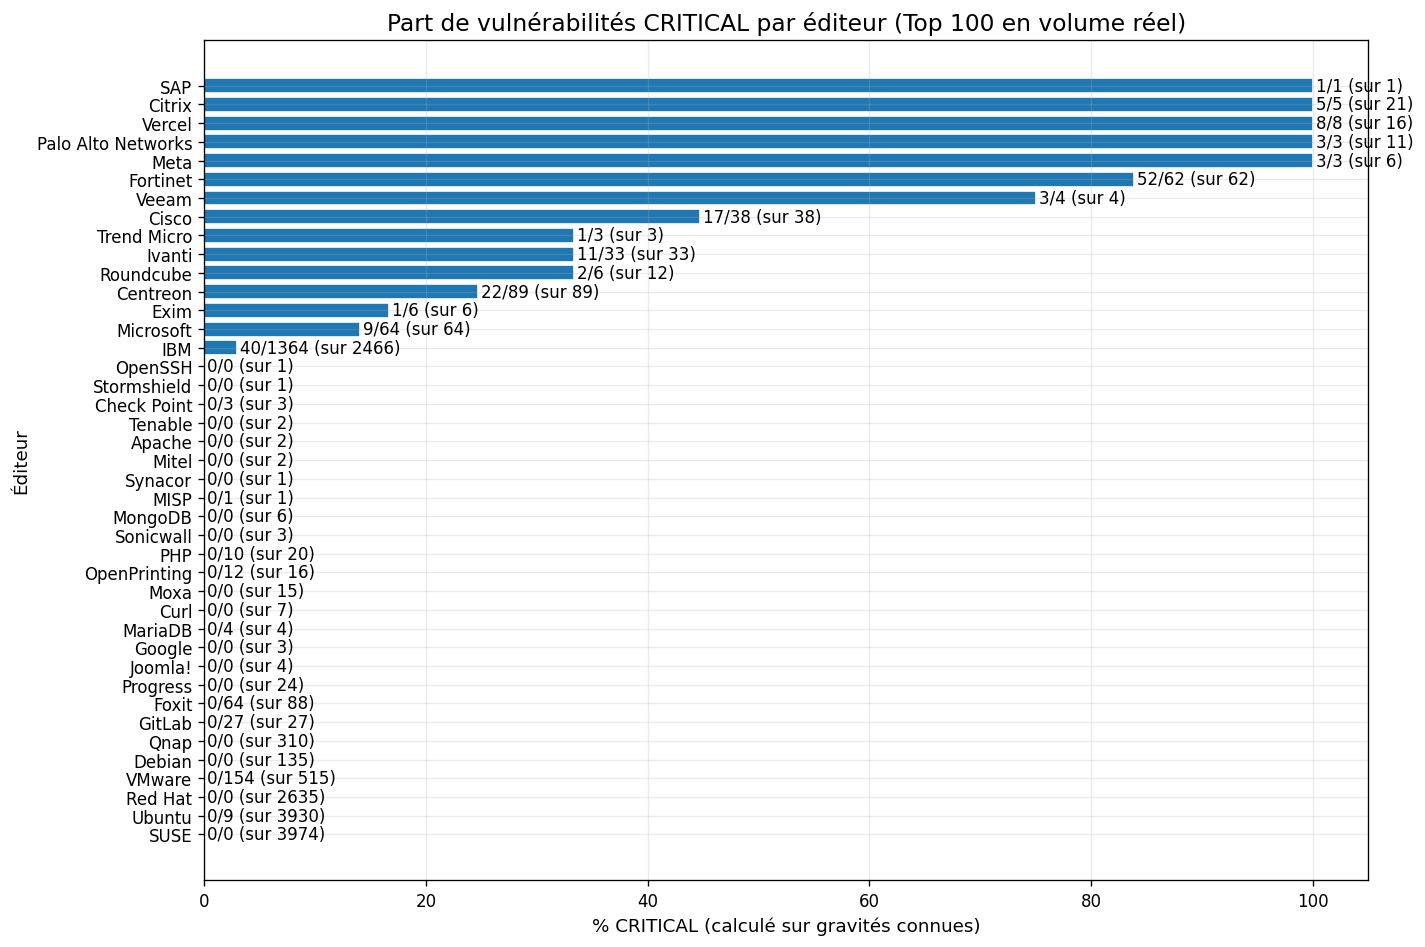

In [ ]:
top_n = 100

# 1) Top N en volume RÉEL (ne dépend pas de la gravité)
ed = (
    df["Éditeur"]
    .astype(str)
    .str.strip()
    .replace({"": np.nan, "nan": np.nan, "None": np.nan})
)

top_v = ed.value_counts().nlargest(top_n).index

# 2) Sous-ensemble sur ces éditeurs (toutes les lignes)
tmp = df.loc[ed.isin(top_v), ["Éditeur", "Gravite_CVSS"]].copy()
tmp["Éditeur"] = tmp["Éditeur"].astype(str).str.strip()

# 3) Normalisation gravité (et on garde Inconnu tel quel, sans dropna)
tmp["Gravite_CVSS"] = (
    tmp["Gravite_CVSS"]
    .astype(str)
    .str.strip()
    .str.upper()
    .replace({"INCONNU": "INCONNU", "INCONNUE": "INCONNU", "INCONNU ": "INCONNU"})
)

# 4) Comptes
total = tmp["Éditeur"].value_counts().reindex(top_v).fillna(0).astype(int)

# gravités connues = tout sauf INCONNU
known_mask = tmp["Gravite_CVSS"].isin(["LOW", "MEDIUM", "HIGH", "CRITICAL"])
known = tmp.loc[known_mask, "Éditeur"].value_counts().reindex(top_v).fillna(0).astype(int)

critical = (
    tmp.loc[tmp["Gravite_CVSS"] == "CRITICAL", "Éditeur"]
    .value_counts()
    .reindex(top_v)
    .fillna(0)
    .astype(int)
)

# % CRITICAL sur gravités connues (si known=0 => 0 mais on l’annotera clairement)
rate = (critical / known.replace(0, np.nan) * 100).fillna(0)

# 5) Table finale (pas d’omission) + tri d’affichage
stats = pd.DataFrame(
    {"rate": rate, "critical": critical, "known": known, "total": total},
    index=top_v
).sort_values("rate", ascending=True)

# 6) Plot
plt.figure(figsize=(12, 8), dpi=120)
plt.barh(stats.index, stats["rate"].values, edgecolor="white", linewidth=1.0)

for y, vendor in enumerate(stats.index):
    c = stats.loc[vendor, "critical"]
    k = stats.loc[vendor, "known"]
    t = stats.loc[vendor, "total"]
    # annotation claire : critical/known (sur total)
    label = f"{c}/{k} (sur {t})"
    plt.text(stats.loc[vendor, "rate"] + 0.3, y, label, va="center")

plt.title(f"Part de vulnérabilités CRITICAL par éditeur (Top {top_n} en volume réel)")
plt.xlabel("% CRITICAL (calculé sur gravités connues)")
plt.ylabel("Éditeur")
plt.tight_layout()
plt.show()

# Cassé, à enlever si je n'arrive pas à le réparer


In [9]:
stats.sort_values("critical", ascending=False)[["critical", "known", "total"]]


,critical,known,total
Éditeur,,,
Fortinet,52,62,62
IBM,40,1364,2466
Centreon,22,89,89
Cisco,17,38,38
Ivanti,11,33,33
Microsoft,9,64,64
Vercel,8,8,16
Citrix,5,5,21
Veeam,3,4,4


In [10]:
print(df["Type_de_Bulletin"].unique())

['Alerte' 'Avis']


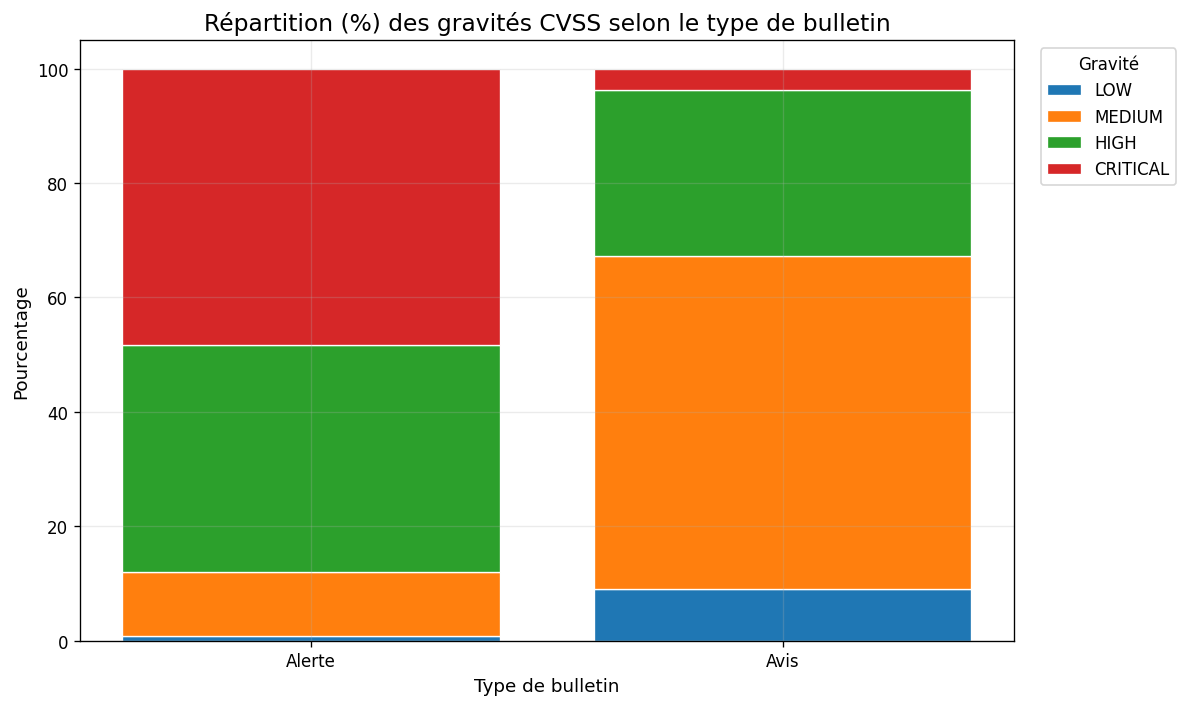

In [11]:
tmp = df[["Type_de_Bulletin", "Gravite_CVSS"]].dropna().copy()
tmp["Gravite_CVSS"] = tmp["Gravite_CVSS"].astype(str).str.upper()

pivot = pd.crosstab(tmp["Type_de_Bulletin"], tmp["Gravite_CVSS"])

for col in ["LOW", "MEDIUM", "HIGH", "CRITICAL"]:
    if col not in pivot.columns:
        pivot[col] = 0

pivot = pivot[["LOW", "MEDIUM", "HIGH", "CRITICAL"]]

pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

plt.figure(figsize=(10, 6), dpi=120)
bottom = np.zeros(len(pivot_pct))
for col in pivot_pct.columns:
    plt.bar(pivot_pct.index, pivot_pct[col].values,
            bottom=bottom, label=col,
            edgecolor="white", linewidth=0.8)
    bottom += pivot_pct[col].values

plt.title("Répartition (%) des gravités CVSS selon le type de bulletin")
plt.xlabel("Type de bulletin")
plt.ylabel("Pourcentage")
plt.legend(title="Gravité", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


Ce graphique compare la répartition relative des niveaux de gravité CVSS en fonction du type de bulletin publié par l’ANSSI, en distinguant les alertes et les avis. Les barres empilées à 100 % permettent d’analyser la structure des gravités indépendamment du volume total de publications pour chaque type de bulletin.

On observe une différence marquée entre les deux catégories. Les alertes sont très majoritairement associées à des vulnérabilités de gravité élevée, avec une part importante de vulnérabilités CRITICAL et HIGH. Les vulnérabilités de gravité LOW et MEDIUM y sont très peu représentées, ce qui confirme que les alertes sont utilisées pour signaler des situations nécessitant une réaction immédiate.

À l’inverse, les avis présentent une répartition plus équilibrée. La majorité des vulnérabilités signalées dans les avis appartient aux catégories MEDIUM et HIGH, tandis que les vulnérabilités CRITICAL y sont beaucoup plus rares. La présence non négligeable de vulnérabilités LOW indique que les avis couvrent également des failles de moindre impact, dans une logique de diffusion large d’information et de bonnes pratiques.

Ce graphique met ainsi en évidence la cohérence du dispositif de publication de l’ANSSI :

les alertes ciblent prioritairement les vulnérabilités les plus graves,

les avis assurent une veille plus globale, couvrant un spectre de gravité plus large.

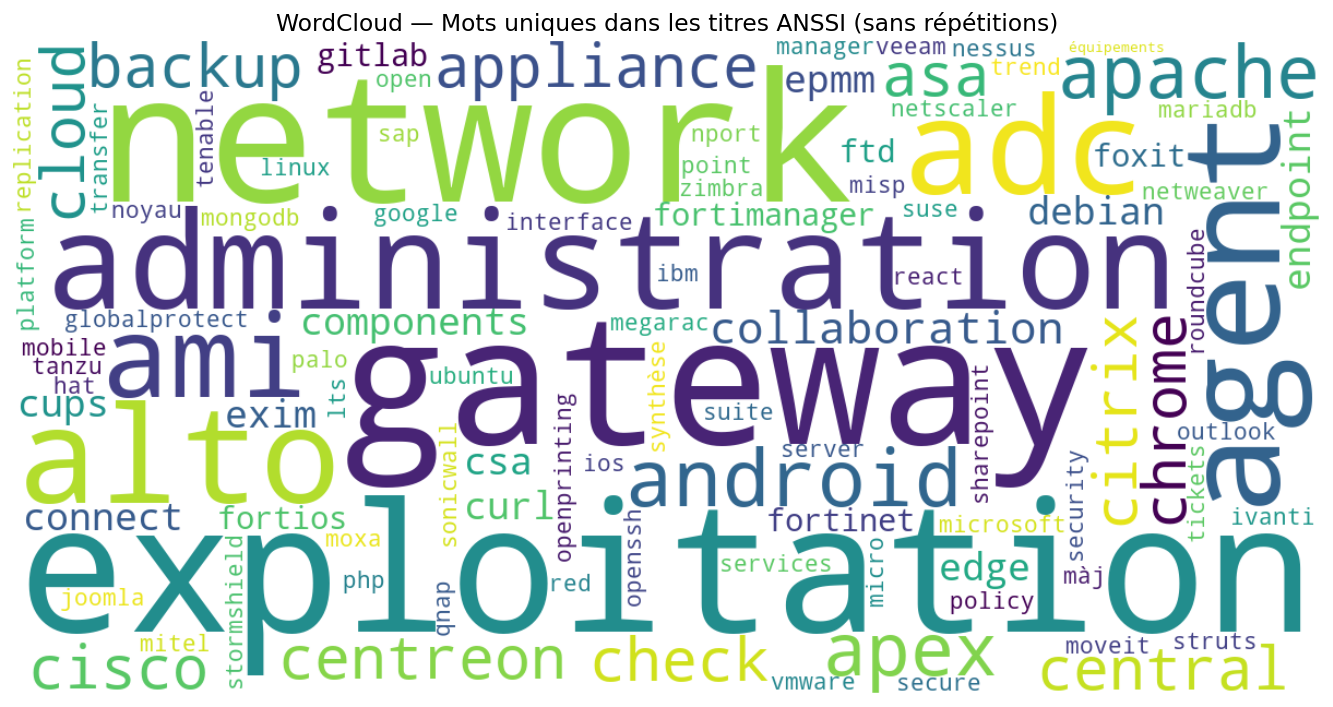

In [14]:
from wordcloud import WordCloud

stopwords_fr = {
    "de","des","du","la","le","les","un","une","et","ou","dans","sur","pour","par","avec","sans",
    "au","aux","en","à","via","plusieurs","multiple","multiples","affectant","affecte","concernant",
    "vulnérabilité","vulnérabilités","faille","failles","sécurité","correctif","mise","jour","anssi",
    "produits","produit"
}

text = (
    df["Titre_ANSSI"].dropna().astype(str).str.lower()
    .str.replace(r"[^a-zàâçéèêëîïôûùüÿñæœ0-9\s-]", " ", regex=True)
)

# ✅ Déduplication GLOBALE : un mot n’apparait qu’une seule fois au total
all_words = []
for s in text:
    words = [w for w in s.split() if w not in stopwords_fr and len(w) > 2]
    all_words.extend(words)

unique_words = sorted(set(all_words))
all_text_unique = " ".join(unique_words)

wc = WordCloud(width=1200, height=600, background_color="white", colormap="viridis").generate(all_text_unique)

plt.figure(figsize=(12, 6), dpi=120)
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud — Mots uniques dans les titres ANSSI (sans répétitions)")
plt.tight_layout()
plt.show()

